<a href="https://colab.research.google.com/github/adanzee/transfer-learning/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Captioning System

This notebook will guide you through building a basic image captioning system using a Convolutional Neural Network (CNN) for image feature extraction and a Recurrent Neural Network (RNN) for caption generation. We will use the Flickr8k dataset, which is suitable for beginners.

### Step 1: Setup and Data Download

In [ ]:
# Install necessary libraries
!pip install tensorflow keras numpy matplotlib scikit-image pandas tqdm -q

In [ ]:
# Import essential libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import string
import re
from tqdm.notebook import tqdm
import urllib.request
import zipfile


In [ ]:
import urllib.request
import zipfile
import os

FLICKR_URL = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
FLICKR_CAPTIONS_URL = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

DATA_DIR = './flickr8k_dataset'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

IMAGE_DIR = os.path.join(DATA_DIR, 'Flicker8k_Dataset')
CAPTIONS_FILE = os.path.join(DATA_DIR, 'Flickr8k.token.txt')

# --- Improved Image Download and Extraction Logic ---
# Check if IMAGE_DIR exists and contains a reasonable number of files (e.g., > 1000 to be sure it's extracted)
expected_num_images = 8092 # Based on the dataset size

if not os.path.exists(IMAGE_DIR) or len(os.listdir(IMAGE_DIR)) < expected_num_images:
    print("Flickr8k_Dataset directory not found or incomplete. Downloading and extracting...")
    image_zip_path = os.path.join(DATA_DIR, 'Flickr8k_Dataset.zip')
    urllib.request.urlretrieve(FLICKR_URL, image_zip_path)
    with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    # Optionally, remove the zip file after extraction
    os.remove(image_zip_path)
    print("Flickr8k_Dataset extracted.")
else:
    print("Flickr8k_Dataset already exists and appears complete.")

# --- Captions Download and Extraction Logic (unchanged as it wasn't the source of error) ---
if not os.path.exists(CAPTIONS_FILE):
    print("Flickr8k_text.zip not found or 'Flickr8k.token.txt' missing. Downloading and extracting...")
    captions_zip_path = os.path.join(DATA_DIR, 'Flickr8k_text.zip')
    urllib.request.urlretrieve(FLICKR_CAPTIONS_URL, captions_zip_path)
    with zipfile.ZipFile(captions_zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    os.remove(captions_zip_path)
    print("Flickr8k_text extracted.")
else:
    print("Flickr8k_text already exists.")

print(f"Image directory: {IMAGE_DIR}")
print(f"Captions file: {CAPTIONS_FILE}")

Flickr8k_Dataset directory not found or incomplete. Downloading and extracting...
Flickr8k_Dataset extracted.
Flickr8k_text already exists.
Image directory: ./flickr8k_dataset/Flicker8k_Dataset
Captions file: ./flickr8k_dataset/Flickr8k.token.txt


### Step 2: Data Loading and Preprocessing

Now we will load the captions and perform text cleaning to prepare them for the model. This includes converting text to lowercase, removing punctuation, and adding start and end tokens to each caption.

In [ ]:
# Load captions
def load_captions(filename):
    with open(filename, 'r') as f:
        text = f.read()
    return text

# Parse captions
def parse_captions(text):
    mapping = {}
    for line in text.split('\n'):
        if not line: # Skip empty lines
            continue
        parts = line.split('\t')
        if len(parts) < 2: # Ensure there are at least two parts (image_id and caption)
            continue
        image_id, caption = parts[0], parts[1]
        image_id = image_id.split('.')[0] # Remove .jpg from image ID

        if image_id not in mapping:
            mapping[image_id] = []
        mapping[image_id].append(caption)
    return mapping

raw_captions = load_captions(CAPTIONS_FILE)
image_captions = parse_captions(raw_captions)

print(f"Total images with captions: {len(image_captions)}")
print(f"Example captions for image '1000268201_693b08cb0e': {image_captions['1000268201_693b08cb0e']}")

Total images with captions: 8092
Example captions for image '1000268201_693b08cb0e': ['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .']


### Text Cleaning and Preprocessing

In [ ]:
# Function to clean text
def clean_text(captions):
    cleaned_captions = {}
    for image_id, caption_list in tqdm(captions.items(), desc="Cleaning Captions"):
        cleaned_list = []
        for i, caption in enumerate(caption_list):
            # Convert to lowercase
            caption = caption.lower()
            # Remove punctuation
            caption = re.sub(f'[{re.escape(string.punctuation)}]', '', caption)
            # Remove numbers
            caption = re.sub(r'\d+', '', caption)
            # Remove words with single characters
            caption = re.sub(r'\b\w\b', '', caption)
            # Remove multiple spaces
            caption = re.sub(r'\s+', ' ', caption).strip()

            # Add start and end tokens
            caption = 'startseq ' + caption + ' endseq'
            cleaned_list.append(caption)
        cleaned_captions[image_id] = cleaned_list
    return cleaned_captions

cleaned_image_captions = clean_text(image_captions)

# Verify cleaning
print(f"Example cleaned captions for image '1000268201_693b08cb0e': {cleaned_image_captions['1000268201_693b08cb0e']}")

Cleaning Captions:   0%|          | 0/8092 [00:00<?, ?it/s]

Example cleaned captions for image '1000268201_693b08cb0e': ['startseq child in pink dress is climbing up set of stairs in an entry way endseq', 'startseq girl going into wooden building endseq', 'startseq little girl climbing into wooden playhouse endseq', 'startseq little girl climbing the stairs to her playhouse endseq', 'startseq little girl in pink dress going into wooden cabin endseq']


### Build Vocabulary

In [ ]:
# Build vocabulary
def build_vocabulary(cleaned_captions):
    all_words = set()
    for image_id, caption_list in cleaned_captions.items():
        for caption in caption_list:
            for word in caption.split():
                all_words.add(word)
    return sorted(list(all_words))

vocabulary = build_vocabulary(cleaned_image_captions)
print(f"Vocabulary size: {len(vocabulary)}")

# Create word to index and index to word mappings
word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}
idx_to_word = {idx: word for idx, word in enumerate(vocabulary)}

# Filter vocabulary based on word frequency (optional, but good practice for smaller datasets)
word_counts = {}
for image_id, caption_list in cleaned_image_captions.items():
    for caption in caption_list:
        for word in caption.split():
            word_counts[word] = word_counts.get(word, 0) + 1

min_word_frequency = 10 # Words appearing less than 10 times will be removed
vocabulary_filtered = [word for word, count in word_counts.items() if count >= min_word_frequency]

# Recreate mappings with filtered vocabulary
word_to_idx_filtered = {word: idx for idx, word in enumerate(vocabulary_filtered)}
idx_to_word_filtered = {idx: word for idx, word in enumerate(vocabulary_filtered)}

# Add 'startseq' and 'endseq' if they were filtered out (shouldn't happen with min_freq=10 but good for robustness)
if 'startseq' not in word_to_idx_filtered: word_to_idx_filtered['startseq'] = len(word_to_idx_filtered)
if 'endseq' not in word_to_idx_filtered: word_to_idx_filtered['endseq'] = len(word_to_idx_filtered)

# Update idx_to_word_filtered
idx_to_word_filtered = {idx: word for word, idx in word_to_idx_filtered.items()}

print(f"Filtered vocabulary size: {len(vocabulary_filtered)}")
print(f"Total unique words after filtering: {len(word_to_idx_filtered)}")

vocabulary_size = len(word_to_idx_filtered)

# Determine maximum caption length
max_caption_length = max(len(caption.split()) for caption_list in cleaned_image_captions.values() for caption in caption_list)
print(f"Maximum caption length: {max_caption_length}")

Vocabulary size: 8767
Filtered vocabulary size: 1949
Total unique words after filtering: 1949
Maximum caption length: 34


### Split Data into Training and Testing Sets

In [ ]:
# Get all image IDs
all_image_ids = list(cleaned_image_captions.keys())

# Split data
train_image_ids, test_image_ids = train_test_split(all_image_ids, test_size=0.2, random_state=42)

print(f"Number of training images: {len(train_image_ids)}")
print(f"Number of testing images: {len(test_image_ids)}")

# Create dictionaries for train and test captions
train_captions = {img_id: cleaned_image_captions[img_id] for img_id in train_image_ids}
test_captions = {img_id: cleaned_image_captions[img_id] for img_id in test_image_ids}

print(f"Example train captions for a random image: {list(train_captions.values())[0]}")

Number of training images: 6473
Number of testing images: 1619
Example train captions for a random image: ['startseq group of boys playing street soccer endseq', 'startseq group of young kids watch group of older kids play soccer on city street endseq', 'startseq children play soccer on narrow city street endseq', 'startseq kids outside on the street playing soccer endseq', 'startseq the boys are playing game of soccer on their neighborhood street endseq']


### Step 3: Feature Extraction with CNN

Next, we will extract features from the images using a pre-trained VGG16 model. These features will serve as input to our RNN model for caption generation.

In [ ]:
# Load the VGG16 model without the top (classification) layer
model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Recreate the model to output the features before the classification layer
model_vgg = Model(inputs=model_vgg.input, outputs=model_vgg.layers[-1].output)

print(model_vgg.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

# Function to preprocess images for VGG16
def preprocess_image(image_path):
    # Load the image and resize it to 224x224 pixels
    img = load_img(image_path, target_size=(224, 224))
    # Convert the image pixels to a numpy array
    img = img_to_array(img)
    # Reshape data for the model
    img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))
    # Preprocess the image for VGG16
    img = preprocess_input(img)
    return img

In [ ]:
# Extract features for all images

image_features = {}

# Filter all_image_ids to only include those that actually have corresponding image files
# This makes the tqdm progress bar accurate to the number of images that will actually be processed
existing_image_ids = []
for img_id in all_image_ids:
    img_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")
    if os.path.exists(img_path):
        existing_image_ids.append(img_id)
    else:
        print(f"Warning: Image file not found for ID: {img_id}. Skipping.")

for image_id in tqdm(existing_image_ids, desc="Extracting Image Features"):
    img_path = os.path.join(IMAGE_DIR, f"{image_id}.jpg") # Construct path for existing ID
    # Preprocess the image
    img = preprocess_image(img_path)
    # Extract features using the VGG16 model
    feature = model_vgg.predict(img, verbose=0)
    # Store the feature vector
    image_features[image_id] = feature

print(f"Extracted features for {len(image_features)} images out of {len(all_image_ids)} total image IDs.")

Extracting Image Features:   0%|          | 0/8091 [00:00<?, ?it/s]

Extracted features for 8091 images out of 8092 total image IDs.


In [ ]:
print(f"Extracted features for {len(image_features)} images.")
print(f"Example feature shape: {image_features[list(image_features.keys())[0]].shape}")

Extracted features for 8091 images.
Example feature shape: (1, 7, 7, 512)


### Step 4: Model Definition and Data Generation

In [ ]:
# Define the captioning model
def define_model(vocabulary_size, max_caption_length):
    # Feature extractor model
    inputs1 = Input(shape=(7, 7, 512)) # VGG16 last conv layer output shape
    fe1 = Dropout(0.5)(inputs1)
    fe2 = tf.keras.layers.Flatten()(fe1)
    fe3 = Dense(256, activation='relu')(fe2)

    # Sequence model
    inputs2 = Input(shape=(max_caption_length,))
    se1 = Embedding(vocabulary_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256, use_cudnn=False)(se2) # Explicitly disable cuDNN

    # Decoder model
    decoder1 = add([fe3, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocabulary_size, activation='softmax')(decoder2)

    # Tie it together [image, seq] [word]
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Get model
model = define_model(vocabulary_size, max_caption_length)
print(model.summary())

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 7, 7, 512) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 7, 7, 512) │          0 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 34, 256)   │    498,944 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 25088)     │          0 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 34, 256)   │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 34)        │          0 │ input_layer_11[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │  6,422,784 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 256)       │    525,312 │ dropout_7[0][0],  │
│                     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ dense_9[0][0],    │
│                     │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │     65,792 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1949)      │    500,893 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,013,725 (30.57 MB)

 Trainable params: 8,013,725 (30.57 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Create data generator
def data_generator(descriptions, features, word_to_idx, max_caption_length, vocabulary_size, batch_size):
    X1, X2, y = list(), list(), list()
    n=0
    while 1:
        for key, desc_list in descriptions.items():
            n+=1
            photo = features[key][0] # Get the 2D feature vector
            for desc in desc_list:
                # Encode the sequence
                seq = [word_to_idx[word] for word in desc.split(' ') if word in word_to_idx]
                for i in range(1, len(seq)):
                    # Split into input and output pair
                    in_seq, out_seq = seq[:i], seq[i]
                    # Pad input sequence (changed to padding='post')
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length, padding='post')[0]
                    # Encode output sequence
                    out_seq = to_categorical([out_seq], num_classes=vocabulary_size)[0]
                    # Store
                    X1.append(photo)
                    X2.append(in_seq)
                    y.append(out_seq)
            if n==batch_size:
                yield ((np.array(X1), np.array(X2)), np.array(y))
                X1, X2, y = list(), list(), list()
                n=0

# Parameters for the data generator
batch_size = 32

### Step 5: Train the Model

Now we will train the image captioning model using the generated image features and captions.

In [ ]:
# Create the training data generator
generator = data_generator(train_captions, image_features, word_to_idx_filtered, max_caption_length, vocabulary_size, batch_size)

# Define the number of epochs
epochs = 10  # You can adjust this value
steps = len(train_captions) // batch_size

# Train the model
print("Starting model training...")
history = model.fit(generator, epochs=epochs, steps_per_epoch=steps, verbose=1)

Starting model training...
Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - accuracy: 0.1439 - loss: 5.3920
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.2213 - loss: 4.3295
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 186s 923ms/step - accuracy: 0.2510 - loss: 4.0933
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 118s 585ms/step - accuracy: 0.2664 - loss: 3.8683
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 117s 580ms/step - accuracy: 0.2799 - loss: 3.6368
Epoch 6/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 90s 445ms/step - accuracy: 0.2892 - loss: 3.5201
Epoch 7/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 85s 420ms/step - accuracy: 0.2966 - loss: 3.4384
Epoch 8/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 95s 474ms/step - accuracy: 0.3029 - loss: 3.3718
Epoch 9/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 76s 375ms/step - accuracy: 0.3070 - loss: 3.3217
Epoch 10/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 58s 287ms/step - accuracy: 0.3098 - loss: 3.2803


### Step 6: Evaluate and Generate Captions

After training, we will evaluate the model by generating captions for unseen images and comparing them with the actual captions. We will also implement a function to generate a caption word by word given an image.

In [ ]:
# Function to map an integer to a word
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.items():
        if index == integer:
            return word
    return None

# Function to generate a caption for an image
def generate_caption(model, photo_feature, tokenizer, max_caption_length):
    # Add the start tag
    in_text = 'startseq'
    # Iterate over the whole length of the caption
    for i in range(max_caption_length):
        # Encode the input sequence
        sequence = [tokenizer[word] for word in in_text.split(' ') if word in tokenizer]
        sequence = pad_sequences([sequence], maxlen=max_caption_length)[0]
        # Predict next word
        yhat = model.predict([photo_feature, np.array([sequence])], verbose=0)
        # Convert probability to integer
        yhat = np.argmax(yhat)
        # Map integer to word
        word = word_for_id(yhat, tokenizer)
        # Stop if word cannot be found
        if word is None:
            break
        # Append as input for generating the next word
        in_text += ' ' + word
        # Stop if we predict the end of the sequence
        if word == 'endseq':
            break
    return in_text

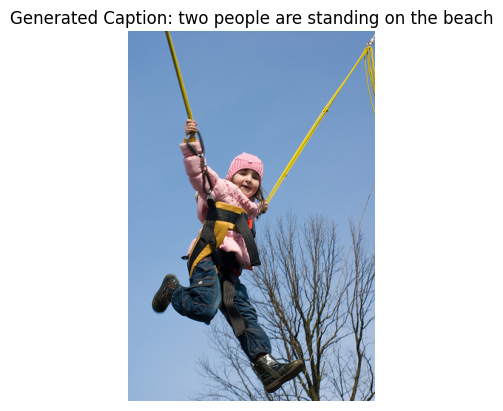

--- Actual Captions for 3477315700_52a4d740a5.jpg ---
little girl in harness is in midair on sunny day
little girl in pink jacket and hat is swinging in harness attached to yellow ropes
young child jumps in bungee seat in front of blue sky and tree
little girl in pink coat on swing
the little girl wearing pink is having fun bungee jumping




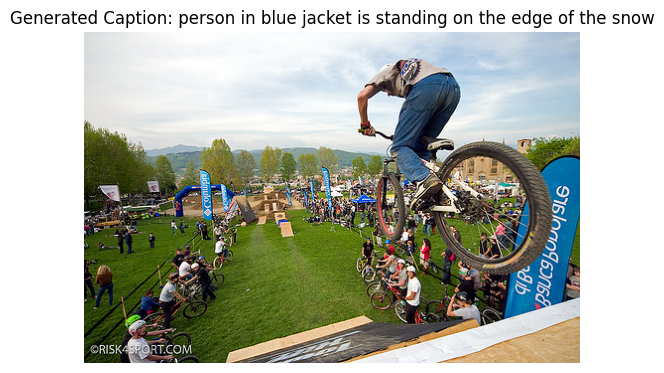

--- Actual Captions for 3530342993_a4a1f0e516.jpg ---
bicycler is going down ramp at bike festival
bike jumps through the air
cyclist is performing stunt in bicyclecross competition
man riding bicycle down ramp towards dirt bike course
stunt cyclist launches himself into midair over ramp while other cyclists watch




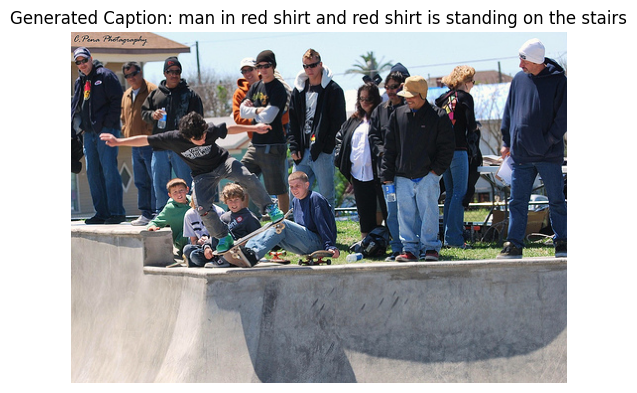

--- Actual Captions for 3404870997_7b0cd755de.jpg ---
group of people stand and look at kid who jumped
group of people watches boy on skateboard launch off ramp
guy on skateboard performs trick in front of crowd
group of people watching skateboarder do tricks at skate park
people are watching boy on skateboard at the top of skate ramp




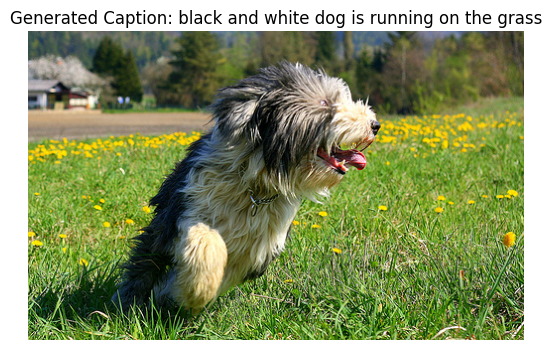

--- Actual Captions for 459814265_d48ba48978.jpg ---
big shaggy dog runs in field of dandylions
dog running in field of daisies
dog sitting in the grass with his tongue out
long haired dog frolics in meadow of yellow flowers
shaggy dog plays in field of grass and yellow flowers




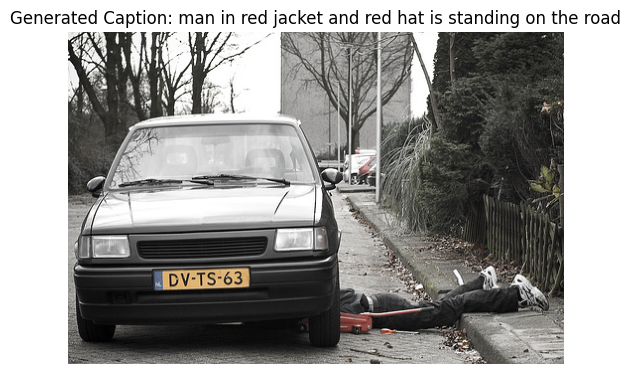

--- Actual Captions for 2092870249_90e3f1855b.jpg ---
man lies on street with his head and shoulders under parked car that is jacked up
man looks under car on wet street
man works on car
person lies half under car facedown
person underneath car with jack




In [ ]:
# Select a few random test images to generate captions for
num_examples = 5
random_test_image_ids = np.random.choice(test_image_ids, num_examples, replace=False)

for image_id in random_test_image_ids:
    # Get the image path
    image_path = os.path.join(IMAGE_DIR, f"{image_id}.jpg")

    # Preprocess the image and extract features
    preprocessed_img = preprocess_image(image_path)
    photo_feature = model_vgg.predict(preprocessed_img, verbose=0)

    # Generate caption
    caption = generate_caption(model, photo_feature, word_to_idx_filtered, max_caption_length)

    # Clean the generated caption for display
    clean_caption = caption.replace('startseq ', '').replace(' endseq', '')

    # Display the image and generated caption
    plt.imshow(load_img(image_path))
    plt.title(f"Generated Caption: {clean_caption}")
    plt.axis('off')
    plt.show()

    print(f"--- Actual Captions for {image_id}.jpg ---")
    for actual_caption in test_captions[image_id]:
        print(actual_caption.replace('startseq ', '').replace(' endseq', ''))
    print("\n")

In [1]:
import plotly.io as pio
# This tells Plotly to include a static image in the notebook output
pio.renderers.default = "notebook_connected+pdf"
